# Q-learning analysis

This notebook studies tabular Q-learning on the simplified Pacman environment.

The experiments evaluate:

- the influence of the learning rate $\alpha$;
- the influence of the discount factor $\gamma$;
- convergence across several random seeds;
- success rate and path optimality.

Each configuration is trained for 1,000 episodes using five seeds. Evaluation is performed without exploration on 200 episodes with random valid starting positions.

In [1]:
from itertools import product
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm.auto import tqdm


project_root = Path.cwd()

if project_root.name == "notebooks":
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))


from pacman_rl.agents.q_learning import QLearningAgent
from pacman_rl.environment import PacmanEnv
from pacman_rl.training import train_q_learning


results_directory = project_root / "results"
data_directory = results_directory / "data"
figures_directory = results_directory / "figures"

figures_directory.mkdir(
    parents=True,
    exist_ok=True,
)

plt.style.use("seaborn-v0_8-whitegrid")

c:\Users\zawad\Documents\MLDM\S9\python project\pacmanRL\Pacman-Reinforcement-learning-Project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
alpha_results = pd.read_csv(
    data_directory / "q_learning_alpha_results.csv"
)

gamma_results = pd.read_csv(
    data_directory / "q_learning_gamma_results.csv"
)

print("Alpha experiments:", len(alpha_results))
print("Gamma experiments:", len(gamma_results))

display(alpha_results.head())
display(gamma_results.head())

Alpha experiments: 20
Gamma experiments: 20


,alpha,seed,training_episodes,last_100_mean_return,success_rate,ghost_rate,timeout_rate,mean_return,return_std,mean_steps,mean_optimal_steps,mean_efficiency_ratio,optimal_path_rate
0,0.01,0,1000,6.55,0.905,0.0,0.095,3.435,14.144107,6.520,3.385,0.905,0.905
1,0.01,1,1000,7.64,0.915,0.0,0.085,3.730,13.418908,6.335,3.530,0.915,0.915
2,0.01,2,1000,6.93,0.930,0.0,0.070,4.660,12.346433,5.570,3.260,0.930,0.930
3,0.01,3,1000,6.73,0.950,0.0,0.050,5.420,10.528704,5.030,3.380,0.950,0.950
4,0.01,4,1000,6.71,0.940,0.0,0.060,4.915,11.439308,5.425,3.445,0.940,0.940


,gamma,seed,training_episodes,last_100_mean_return,success_rate,ghost_rate,timeout_rate,mean_return,return_std,mean_steps,mean_optimal_steps,mean_efficiency_ratio,optimal_path_rate
0,0.5,0,1000,7.03,1.0,0.0,0.0,7.615,1.840319,3.385,3.385,1.0,1.0
1,0.5,1,1000,7.78,1.0,0.0,0.0,7.470,1.881250,3.530,3.530,1.0,1.0
2,0.5,2,1000,6.65,1.0,0.0,0.0,7.740,1.833685,3.260,3.260,1.0,1.0
3,0.5,3,1000,7.36,1.0,0.0,0.0,7.620,1.722092,3.380,3.380,1.0,1.0
4,0.5,4,1000,6.97,1.0,0.0,0.0,7.555,1.702050,3.445,3.445,1.0,1.0


In [3]:
alpha_summary = alpha_results.groupby("alpha").agg(
    success_rate_mean=("success_rate", "mean"),
    success_rate_std=("success_rate", "std"),
    timeout_rate_mean=("timeout_rate", "mean"),
    training_return_mean=(
        "last_100_mean_return",
        "mean",
    ),
    training_return_std=(
        "last_100_mean_return",
        "std",
    ),
    efficiency_mean=(
        "mean_efficiency_ratio",
        "mean",
    ),
    optimal_path_rate_mean=(
        "optimal_path_rate",
        "mean",
    ),
)

gamma_summary = gamma_results.groupby("gamma").agg(
    success_rate_mean=("success_rate", "mean"),
    success_rate_std=("success_rate", "std"),
    training_return_mean=(
        "last_100_mean_return",
        "mean",
    ),
    training_return_std=(
        "last_100_mean_return",
        "std",
    ),
    efficiency_mean=(
        "mean_efficiency_ratio",
        "mean",
    ),
    optimal_path_rate_mean=(
        "optimal_path_rate",
        "mean",
    ),
)

print("Learning-rate comparison")
display(alpha_summary.round(3))

print("Discount-factor comparison")
display(gamma_summary.round(3))

Learning-rate comparison


,success_rate_mean,success_rate_std,timeout_rate_mean,training_return_mean,training_return_std,efficiency_mean,optimal_path_rate_mean
alpha,,,,,,,
0.01,0.928,0.018,0.072,6.912,0.429,0.928,0.928
0.10,1.000,0.000,0.000,7.280,0.357,1.000,1.000
0.50,1.000,0.000,0.000,7.288,0.432,1.000,1.000
0.90,1.000,0.000,0.000,7.214,0.331,1.000,1.000


Discount-factor comparison


,success_rate_mean,success_rate_std,training_return_mean,training_return_std,efficiency_mean,optimal_path_rate_mean
gamma,,,,,,
0.50,1.0,0.0,7.158,0.429,1.0,1.0
0.70,1.0,0.0,7.210,0.414,1.0,1.0
0.90,1.0,0.0,7.302,0.298,1.0,1.0
0.99,1.0,0.0,7.280,0.357,1.0,1.0


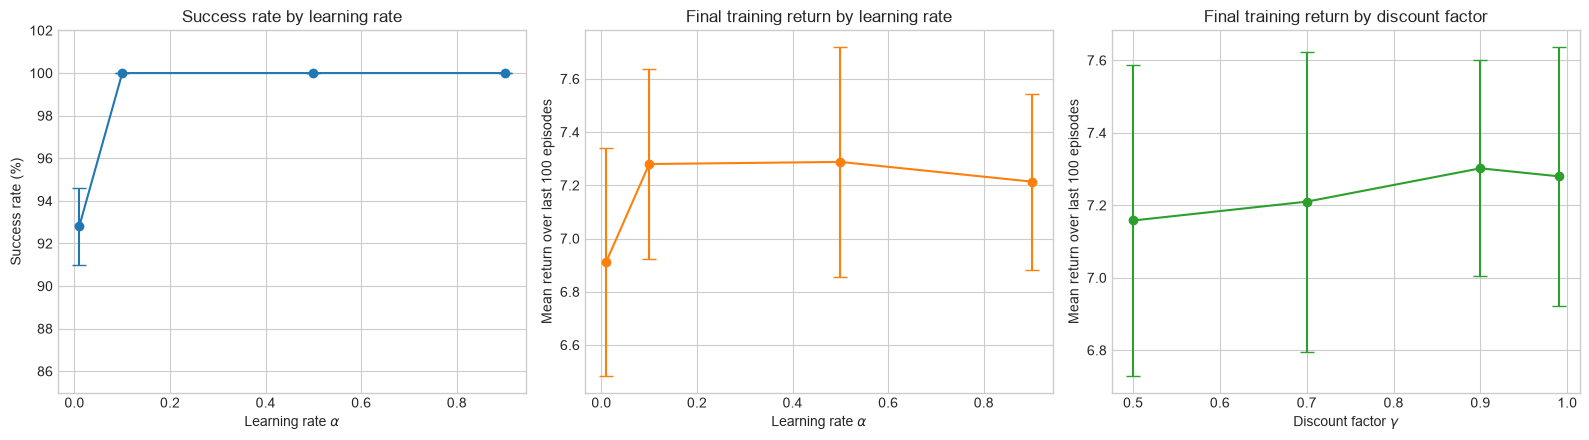

Figure saved to c:\Users\zawad\Documents\MLDM\S9\python project\pacmanRL\Pacman-Reinforcement-learning-Project\results\figures\q_learning_parameter_summary.png


In [4]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(16, 4.5),
)

alpha_x = alpha_summary.index.to_numpy()
gamma_x = gamma_summary.index.to_numpy()

axes[0].errorbar(
    alpha_x,
    100 * alpha_summary["success_rate_mean"],
    yerr=100 * alpha_summary["success_rate_std"].fillna(0),
    marker="o",
    capsize=5,
)

axes[0].set_title("Success rate by learning rate")
axes[0].set_xlabel(r"Learning rate $\alpha$")
axes[0].set_ylabel("Success rate (%)")
axes[0].set_ylim(85, 102)

axes[1].errorbar(
    alpha_x,
    alpha_summary["training_return_mean"],
    yerr=alpha_summary["training_return_std"].fillna(0),
    marker="o",
    capsize=5,
    color="tab:orange",
)

axes[1].set_title("Final training return by learning rate")
axes[1].set_xlabel(r"Learning rate $\alpha$")
axes[1].set_ylabel("Mean return over last 100 episodes")

axes[2].errorbar(
    gamma_x,
    gamma_summary["training_return_mean"],
    yerr=gamma_summary["training_return_std"].fillna(0),
    marker="o",
    capsize=5,
    color="tab:green",
)

axes[2].set_title("Final training return by discount factor")
axes[2].set_xlabel(r"Discount factor $\gamma$")
axes[2].set_ylabel("Mean return over last 100 episodes")

fig.tight_layout()

summary_figure_path = (
    figures_directory
    / "q_learning_parameter_summary.png"
)

fig.savefig(
    summary_figure_path,
    dpi=160,
    bbox_inches="tight",
)

plt.show()

print(f"Figure saved to {summary_figure_path}")

In [5]:
def collect_learning_curves(
    parameter_name,
    parameter_values,
    seeds,
    episodes=1000,
    rolling_window=50,
):
    records = []

    combinations = list(
        product(parameter_values, seeds)
    )

    for parameter_value, seed in tqdm(
        combinations,
        desc=f"Running {parameter_name} experiments",
    ):
        alpha = (
            parameter_value
            if parameter_name == "alpha"
            else 0.1
        )

        gamma = (
            parameter_value
            if parameter_name == "gamma"
            else 0.99
        )

        env = PacmanEnv(
            random_start=True,
            seed=seed,
        )

        agent = QLearningAgent(
            n_states=env.rows * env.cols,
            n_actions=env.n_actions,
            alpha=alpha,
            gamma=gamma,
            epsilon=1.0,
            epsilon_min=0.05,
            epsilon_decay=0.995,
            seed=seed,
        )

        history = train_q_learning(
            env=env,
            agent=agent,
            episodes=episodes,
        )

        smoothed_returns = (
            pd.Series(history.episode_returns)
            .rolling(
                window=rolling_window,
                min_periods=1,
            )
            .mean()
        )

        for episode, smoothed_return in enumerate(
            smoothed_returns,
            start=1,
        ):
            records.append(
                {
                    parameter_name: parameter_value,
                    "seed": seed,
                    "episode": episode,
                    "smoothed_return": smoothed_return,
                }
            )

    return pd.DataFrame(records)

In [6]:
seeds = [0, 1, 2, 3, 4]

alpha_curves = collect_learning_curves(
    parameter_name="alpha",
    parameter_values=[0.01, 0.1, 0.5, 0.9],
    seeds=seeds,
)

gamma_curves = collect_learning_curves(
    parameter_name="gamma",
    parameter_values=[0.5, 0.7, 0.9, 0.99],
    seeds=seeds,
)

print("Alpha curve rows:", len(alpha_curves))
print("Gamma curve rows:", len(gamma_curves))

Running gamma experiments: 100%|██████████| 20/20 [00:02<00:00,  7.71it/s]


Alpha curve rows: 20000
Gamma curve rows: 20000


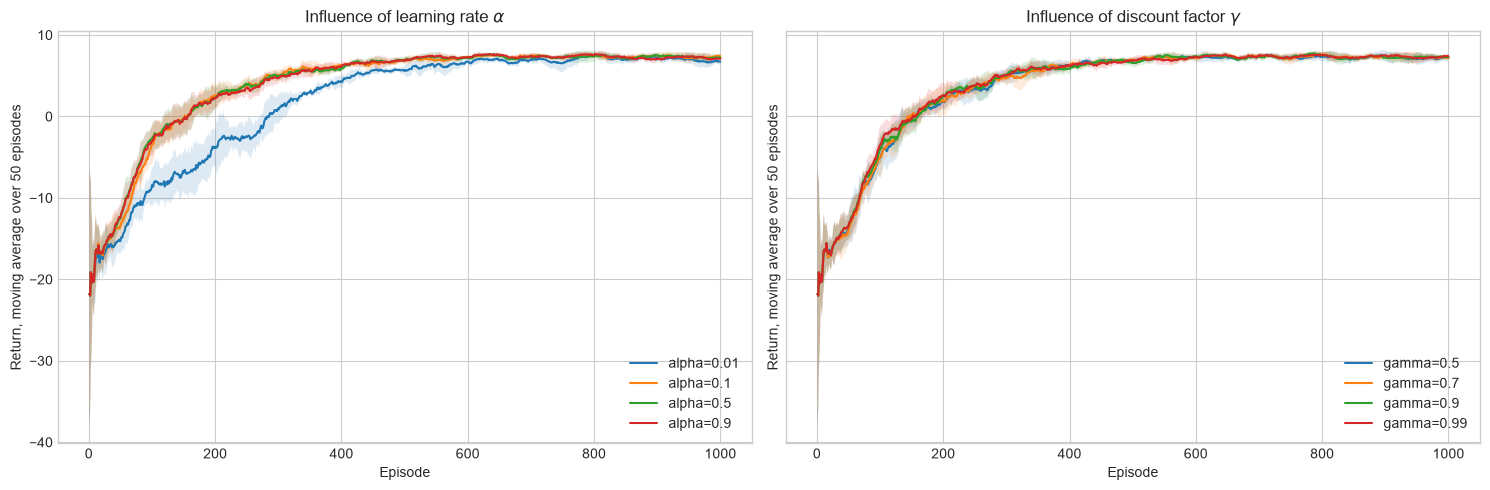

Figure saved to c:\Users\zawad\Documents\MLDM\S9\python project\pacmanRL\Pacman-Reinforcement-learning-Project\results\figures\q_learning_parameter_curves.png


In [7]:
def plot_learning_curves(
    data,
    parameter_name,
    axis,
):
    summary = (
        data.groupby(
            [parameter_name, "episode"]
        )["smoothed_return"]
        .agg(["mean", "std"])
        .reset_index()
    )

    for parameter_value in sorted(
        data[parameter_name].unique()
    ):
        parameter_data = summary[
            summary[parameter_name] == parameter_value
        ]

        episodes = parameter_data["episode"].to_numpy()
        means = parameter_data["mean"].to_numpy()
        standard_deviations = (
            parameter_data["std"]
            .fillna(0)
            .to_numpy()
        )

        axis.plot(
            episodes,
            means,
            label=f"{parameter_name}={parameter_value}",
        )

        axis.fill_between(
            episodes,
            means - standard_deviations,
            means + standard_deviations,
            alpha=0.15,
        )

    axis.set_xlabel("Episode")
    axis.set_ylabel("Return, moving average over 50 episodes")
    axis.legend()


fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 5),
    sharey=True,
)

plot_learning_curves(
    alpha_curves,
    "alpha",
    axes[0],
)

axes[0].set_title(
    r"Influence of learning rate $\alpha$"
)

plot_learning_curves(
    gamma_curves,
    "gamma",
    axes[1],
)

axes[1].set_title(
    r"Influence of discount factor $\gamma$"
)

fig.tight_layout()

curves_figure_path = (
    figures_directory
    / "q_learning_parameter_curves.png"
)

fig.savefig(
    curves_figure_path,
    dpi=160,
    bbox_inches="tight",
)

plt.show()

print(f"Figure saved to {curves_figure_path}")

## Interpretation

### Learning rate

The learning rate has a visible influence on convergence. With $\alpha=0.01$, updates of the Q-table are small and learning remains incomplete after 1,000 episodes. The mean success rate is 92.8%, with 7.2% timeouts.

For $\alpha \in \{0.1, 0.5, 0.9\}$, all five seeds reach a 100% success rate and a 100% optimal-path rate. The environment is deterministic, so large learning rates do not destabilize the final policy in this experiment. We retain $\alpha=0.1$ as a conservative compromise.

### Discount factor

All tested values of $\gamma$ between 0.5 and 0.99 produce an optimal final policy after 1,000 episodes. The reference grid is small, and the PAC-DOT reward can be propagated through the state space even with a relatively low discount factor.

No significant influence of $\gamma$ is observed on final performance. We retain $\gamma=0.99$ because future rewards will be more important on larger grids.

## Conclusion

Tabular Q-learning successfully solves the fixed Pacman environment. With $\alpha=0.1$ and $\gamma=0.99$, the learned policy reaches the PAC-DOT from all evaluated starting positions, avoids the ghost, and follows a shortest safe path.

The next experiments will evaluate how the method scales when the size of the grid increases.